In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, expon, uniform, laplace
from scipy.stats import skew, kurtosis, mode
from scipy.optimize import minimize
from scipy.optimize import curve_fit

In [10]:
data = np.load('sunspot.npz')
B= data['B']
theta = np.degrees(data['inc'])
phi = np.degrees(data['az'])

## PRVI ZADATAK

Potrebno je prikazati mape i histograme za B, $\theta$ i $\phi$ pojedinačno.

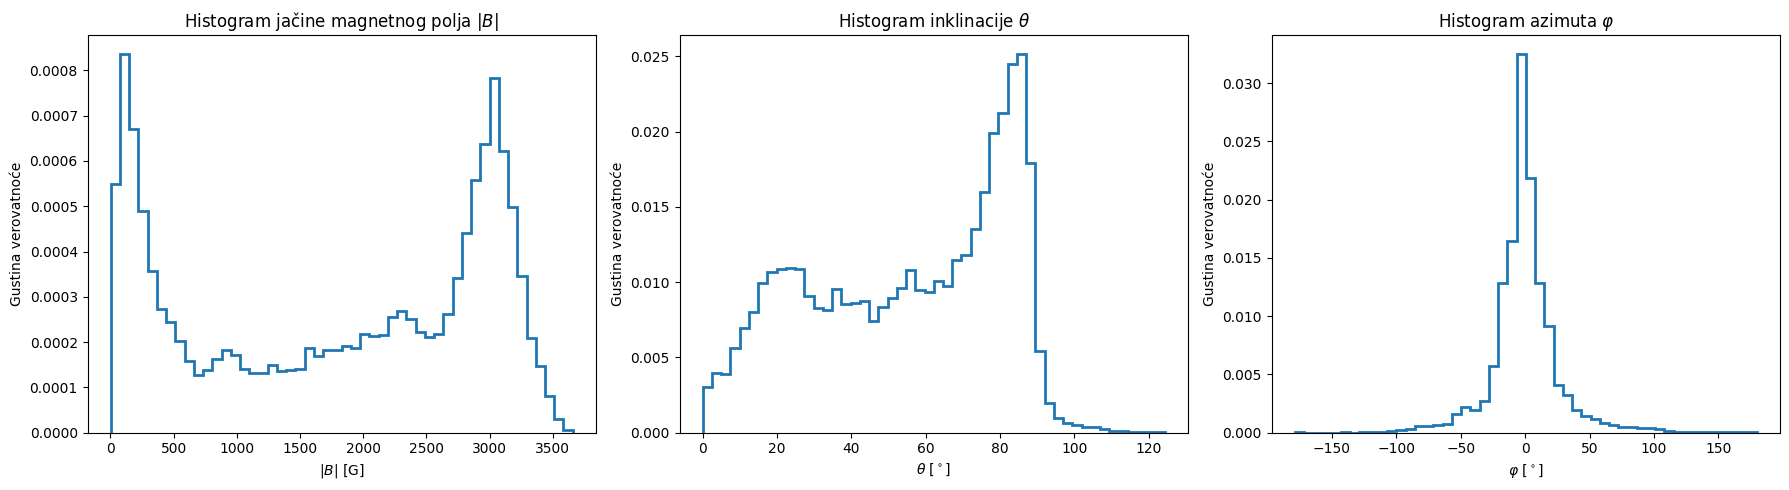

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram za magnetno polje
axes[0].hist(B.flatten(), density=True, bins=50, histtype='step', linewidth=2)
axes[0].set_title(r'Histogram jačine magnetnog polja $|B|$')
axes[0].set_xlabel(r'$|B|$ [G]')
axes[0].set_ylabel('Gustina verovatnoće')

# Histogram za inklinaciju
axes[1].hist(theta.flatten(), density=True, bins=50, histtype='step', linewidth=2)
axes[1].set_title(r'Histogram inklinacije $\theta$')
axes[1].set_xlabel(r'$\theta$ [$^\circ$]')
axes[1].set_ylabel('Gustina verovatnoće')

# Histogram za azimut
axes[2].hist(phi.flatten(), density=True, bins=50, histtype='step', linewidth=2)
axes[2].set_title(r'Histogram azimuta $\varphi$')
axes[2].set_xlabel(r'$\varphi$ [$^\circ$]')
axes[2].set_ylabel('Gustina verovatnoće')

plt.tight_layout()
plt.show()

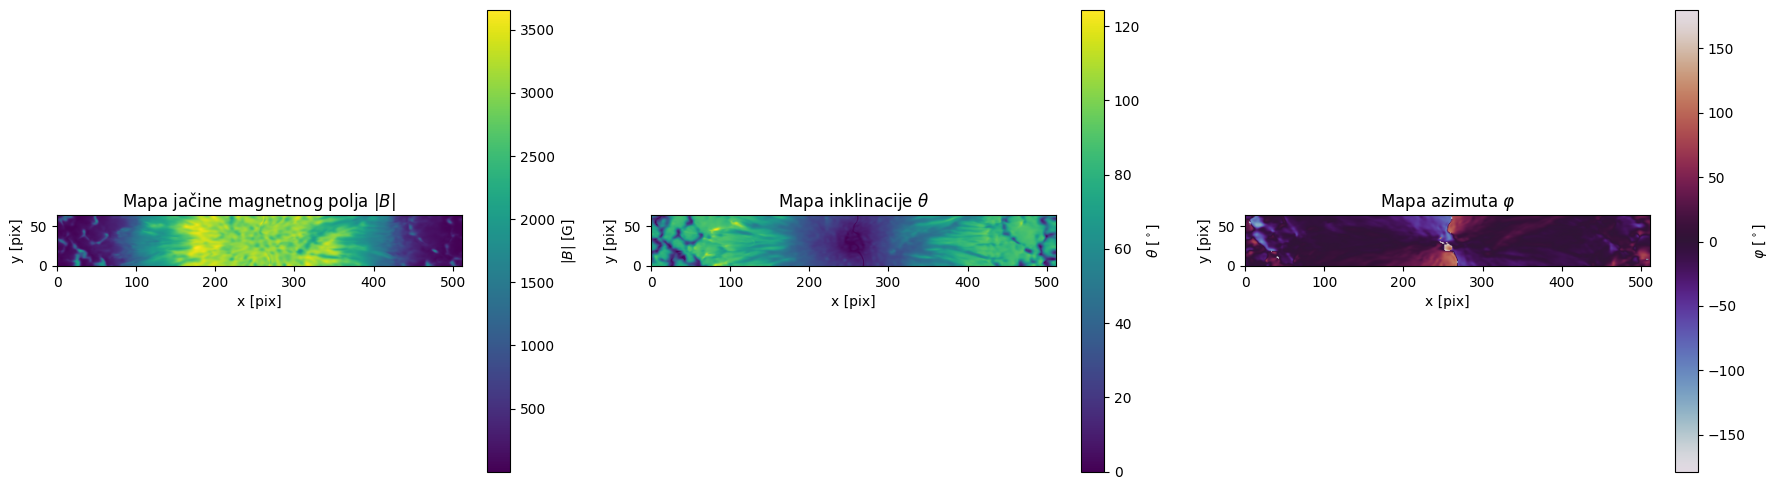

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Mapa za magnetno polje
im0 = axes[0].imshow(B, origin='lower', cmap='viridis')
axes[0].set_title(r'Mapa jačine magnetnog polja $|B|$')
axes[0].set_xlabel('x [pix]')
axes[0].set_ylabel('y [pix]')
fig.colorbar(im0, ax=axes[0], label=r'$|B|$ [G]')

# Mapa za inklinaciju
im1 = axes[1].imshow(theta, origin='lower', cmap='viridis')
axes[1].set_title(r'Mapa inklinacije $\theta$')
axes[1].set_xlabel('x [pix]')
axes[1].set_ylabel('y [pix]')
fig.colorbar(im1, ax=axes[1], label=r'$\theta$ [$^\circ$]')

# Mapa za azimut
im2 = axes[2].imshow(phi, origin='lower', cmap='twilight')
axes[2].set_title(r'Mapa azimuta $\varphi$')
axes[2].set_xlabel('x [pix]')
axes[2].set_ylabel('y [pix]')
fig.colorbar(im2, ax=axes[2], label=r'$\varphi$ [$^\circ$]')

plt.tight_layout()
plt.show()

## DRUGI ZADATAK

Magnetno polje modelovati funkcijom raspodele verovatnoće koja je kombinacija normalne, eksponencijalne i uniformne raspodele.
Inklinaciju modelovati raspodelom koja je kombinacija normalne i eksponencijalne raspodele.
Što se tiče azimuta, iskoristiti Laplasovu funkciju raspodele. 

Plotovati krive dobijenih funkcija preko histograma, pojedinačno.

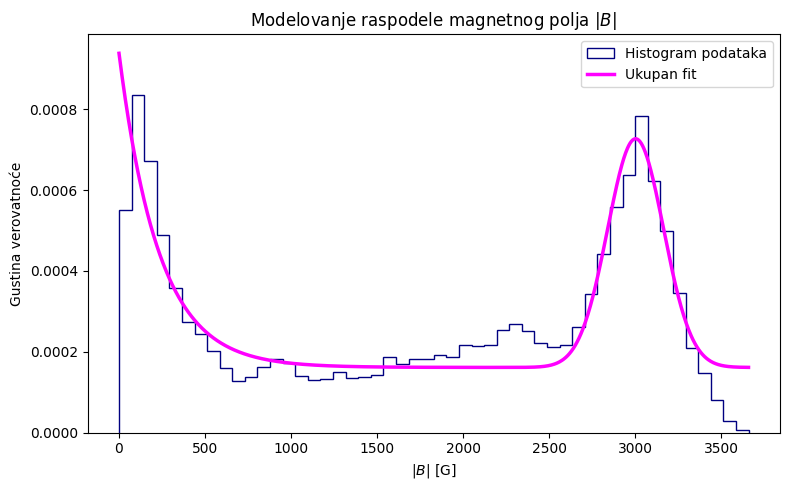

Parametri za magnetno polje modelovano funkcijom tri raspodele:
w_norm  = 0.23
w_exp   = 0.18
w_uni   = 0.59
mu_B    = 3001.49
sigma_B = 162.19
scale_B = 232.0


In [22]:
#MAGNETNO POLJE

B_1d = B.flatten()         #pretvaramo matricu vrednosti u jedan niz

B_min = np.min(B_1d)       
B_max = np.max(B_1d)
B_opseg = B_max - B_min    #najmanje i najveće vrednosti da bismo našli širinu intervala u kom se nalaze podaci zbog uniformne raspodele


def softmax(a, b, c):      #računamo težine raspodela tako da dobijemo da njihov zbir bude 1 i da su sve pozitivne
    vals = np.exp([a, b, c])
    return vals / np.sum(vals)


#Ukupna raspodela: normalna + eksponencijalna + uniformna
def B_model(x, params):
    a, b, c, mu, log_sigma, log_scale = params    #svi parametri koje dobijamo, težine raspodela, srednju vr. i standardnu devijaciju normalne i skalu eksponencijalne

    w_norm, w_exp, w_uni = softmax(a, b, c)

    sigma = np.exp(log_sigma)      #vraćamo se na originalne parametre ali su pod uslovom da su >0
    scale = np.exp(log_scale)

    pdf = (
        w_norm * norm.pdf(x, loc=mu, scale=sigma)
        + w_exp * expon.pdf(x, loc=B_min, scale=scale)
        + w_uni * uniform.pdf(x, loc=B_min, scale=B_opseg)      #dobijamo ukupnu gustinu verovatnoće sa ove tri raspodele
    )

    return pdf

#Gledamo koliko nam se podaci slažu sa modelom
def neg_log_likelihood(params):
    pdf = B_model(B_1d, params)
    return -np.sum(np.log(pdf))

#Zadajemo inicijane vrednosti parametara
p_0 = [
    1, 1, 1,
    np.mean(B_1d),
    np.log(np.std(B_1d)),
    np.log(np.std(B_1d))
]

#Fitujemo
result = minimize(
    neg_log_likelihood,
    p_0,
    method='Nelder-Mead'
)

params = result.x

#Izvlačimo parametre
a, b, c, mu_B, log_sigma_B, log_scale_B = params

w_norm_B, w_exp_B, w_uni_B = softmax(a, b, c)
sigma_B = np.exp(log_sigma_B)
scale_B = np.exp(log_scale_B)


#Plotovanje i iscrtavanje fita
B_fit = np.linspace(B_min, B_max, 1000)
pdf_fit = B_model(B_fit, params)

plt.figure(figsize=(8, 5))

plt.hist(
    B_1d,
    bins=50,
    histtype='step',
    density=True,
    color='navy',
    label='Histogram podataka'
)

plt.plot(
    B_fit,
    pdf_fit,
    linewidth=2.5,
    color='magenta',
    label='Ukupan fit'
)

plt.xlabel(r'$|B|$ [G]')
plt.ylabel('Gustina verovatnoće')
plt.title(r'Modelovanje raspodele magnetnog polja $|B|$')
plt.legend()
plt.tight_layout()
plt.show()


print("Parametri za magnetno polje modelovano funkcijom tri raspodele:")
print("w_norm  =", np.round(w_norm_B,2))
print("w_exp   =", np.round(w_exp_B, 2))
print("w_uni   =", np.round(w_uni_B, 2))
print("mu_B    =", np.round(mu_B, 2))
print("sigma_B =", np.round(sigma_B, 2))
print("scale_B =", np.round(scale_B))

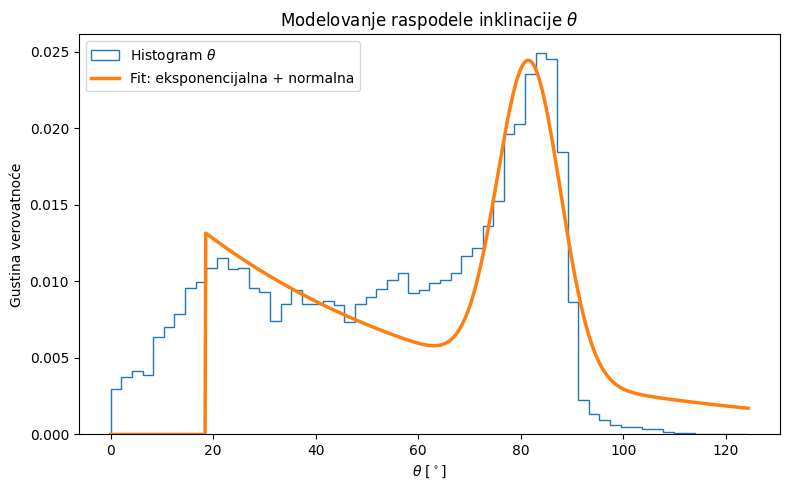

Parametri za inklinaciju modelovanu funkcijom dve raspodele:
w_exp   = 0.68
w_norm  = 0.32
theta0  = 18.47
scale   = 51.9
mu      = 81.6
sigma   = 6.14


In [24]:
#INKLINACIJA

theta_1d = theta.flatten()

theta_min = np.min(theta_1d)
theta_max = np.max(theta_1d)

# Histogram koji fitujemo
hist_theta, bins_theta = np.histogram(theta_1d, bins=60, density=True)
x_theta = 0.5 * (bins_theta[:-1] + bins_theta[1:])

# Model: eksponencijalna + normalna raspodela
def theta_model(x, a_exp, a_norm, theta0, scale, mu, sigma):
    suma = a_exp + a_norm

    w_exp = a_exp / suma
    w_norm = a_norm / suma

    pdf_exp = expon.pdf(x, loc=theta0, scale=scale)
    pdf_norm = norm.pdf(x, loc=mu, scale=sigma)

    return w_exp * pdf_exp + w_norm * pdf_norm

# Početne pretpostavke
p0_theta = [
    0.4,    # doprinos eksponencijalne raspodele
    0.6,    # doprinos normalne raspodele
    15,     # theta0 - početak eksponencijalne raspodele
    25,     # scale eksponencijalne raspodele
    85,     # mu normalne raspodele
    7       # sigma normalne raspodele
]

# Granice parametara
bounds_theta = (
    [0, 0, 0, 1, 70, 2],       
    [1, 1, 35, 80, 95, 25]     
)

# Fit
theta_par, _ = curve_fit(
    theta_model,
    x_theta,
    hist_theta,
    p0=p0_theta,
    bounds=bounds_theta,
    maxfev=20000
)

# Parametri fita
a_exp, a_norm, theta0, scale_theta, mu_theta, sigma_theta = theta_par

w_exp_theta = a_exp / (a_exp + a_norm)
w_norm_theta = a_norm / (a_exp + a_norm)

# Crtanje
x_fit = np.linspace(theta_min, theta_max, 1000)

plt.figure(figsize=(8, 5))

plt.hist(
    theta_1d,
    bins=60,
    density=True,
    histtype='step',
    label=r'Histogram $\theta$'
)

plt.plot(
    x_fit,
    theta_model(x_fit, *theta_par),
    linewidth=2.5,
    label='Fit: eksponencijalna + normalna'
)

plt.xlabel(r'$\theta$ [$^\circ$]')
plt.ylabel('Gustina verovatnoće')
plt.title(r'Modelovanje raspodele inklinacije $\theta$')
plt.legend()
plt.tight_layout()
plt.show()

print("Parametri za inklinaciju modelovanu funkcijom dve raspodele:")
print("w_exp   =", np.round(w_exp_theta, 2))
print("w_norm  =", np.round(w_norm_theta, 2))
print("theta0  =", np.round(theta0, 2))
print("scale   =", np.round(scale_theta, 2))
print("mu      =", np.round(mu_theta, 2))
print("sigma   =", np.round(sigma_theta, 2))

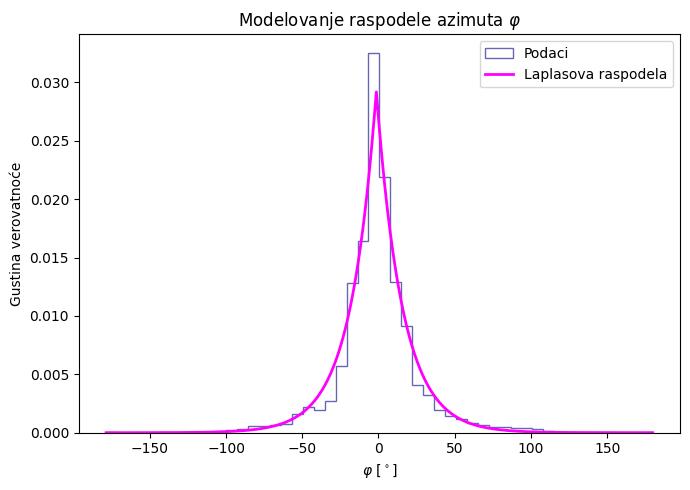

Parametri za azimut modelovan funkcijom Laplasove raspodele:
loc   = -1.43
scale = 17.09


In [21]:
#AZIMUT
phi_1d = phi.flatten()

loc_phi, scale_phi = laplace.fit(phi_1d)

#Plotovanje
x_plot = np.linspace(np.min(phi_1d), np.max(phi_1d), 1000)

pdf_phi = laplace.pdf(x_plot, loc=loc_phi, scale=scale_phi)

plt.figure(figsize=(7, 5))

plt.hist(phi_1d, bins=50, histtype='step', density=True, alpha=0.6, color='navy', label='Podaci')
plt.plot(x_plot, pdf_phi, linewidth=2, color='magenta', label='Laplasova raspodela')

plt.xlabel(r'$\varphi$ [$^\circ$]')
plt.ylabel('Gustina verovatnoće')
plt.title(r'Modelovanje raspodele azimuta $\varphi$')
plt.legend()

plt.tight_layout()
plt.show()

print("Parametri za azimut modelovan funkcijom Laplasove raspodele:")
print("loc   =", np.round(loc_phi, 2))
print("scale =", np.round(scale_phi, 2))

## TREĆI ZADATAK

Za svaki od parametara naći $\bar{x}$, s, medijanu, $\sigma_G$ ($\bar{x}$ i medijanu nacrtati kao vertikalne linije preko histograma), asimetričnost i kurtosis. Komentarisati robusnost deskriptivnih statistika. Parametar $\sigma_G$ računati preko $\sigma_G = q_{75} - q_{25}$.

Srednja vrijednost: 1795.60
Medijana:2043.23
Varijansa:1354138.38
Standardna devijacija: 1163.67
Asimetričnost: -0.24
Kurtosis: -1.50
Mod: 190.87
25. percentil: 511.98
50. percentil: 2043.23
75. percentil: 2919.10
Devijacija:2407.12


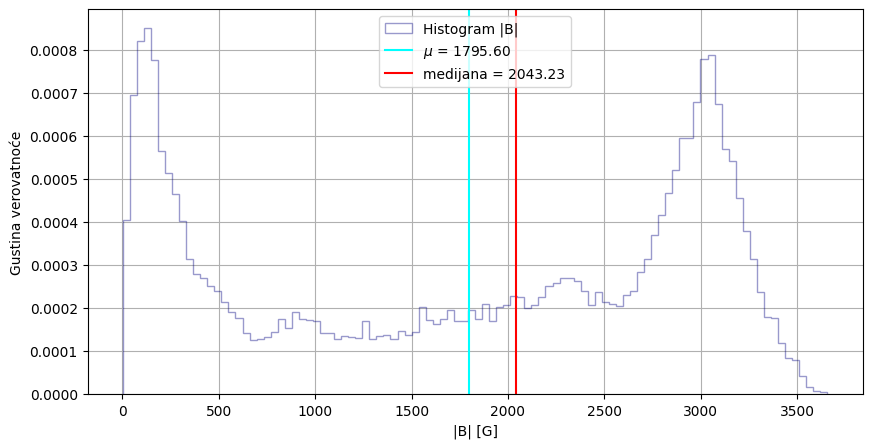

In [16]:
# Statistika vrednosti magnetnog polja
sv = np.mean(B_1d)
medijana = np.median(B_1d)
varijansa = np.var(B_1d)
stdev = np.std(B_1d)
s = skew(B_1d)
k = kurtosis(B_1d)
moda = mode(B_1d)
q25, q50, q75 = np.percentile(B_1d, [25, 50, 75])
devG=q75-q25 

print(f"Srednja vrijednost: {sv:.2f}")
print(f"Medijana:{medijana:.2f}")
print(f"Varijansa:{varijansa:.2f}")
print(f"Standardna devijacija: {stdev:.2f}")
print(f"Asimetričnost: {s:.2f}")
print(f"Kurtosis: {k:.2f}")
print(f"Mod: {moda[0]:.2f}")
print(f"25. percentil: {q25:.2f}")
print(f"50. percentil: {q50:.2f}")
print(f"75. percentil: {q75:.2f}")
print(f"Devijacija:{devG:.2f}")


plt.figure(figsize=(10, 5))
plt.hist(B_1d, bins=100, density=True, histtype='step', alpha=0.4, color='navy', label='Histogram |B|')
plt.axvline(sv, color='cyan', linestyle='-', label=fr'$\mu$ = {sv:.2f}')
plt.axvline(medijana, color='red', linestyle='-', label=fr'medijana = {medijana:.2f}')
plt.xlabel('|B| [G]')
plt.ylabel('Gustina verovatnoće')
plt.title('')
plt.legend()
plt.grid()
plt.show()

Srednja vrijednost: 55.36
Medijana:59.85
Varijansa:691.98
Standardna devijacija: 26.31
Asimetričnost: -0.34
Kurtosis: -1.18
Mod: 0.00
25. percentil: 31.78
50. percentil: 59.85
75. percentil: 79.48
Devijacija:47.70


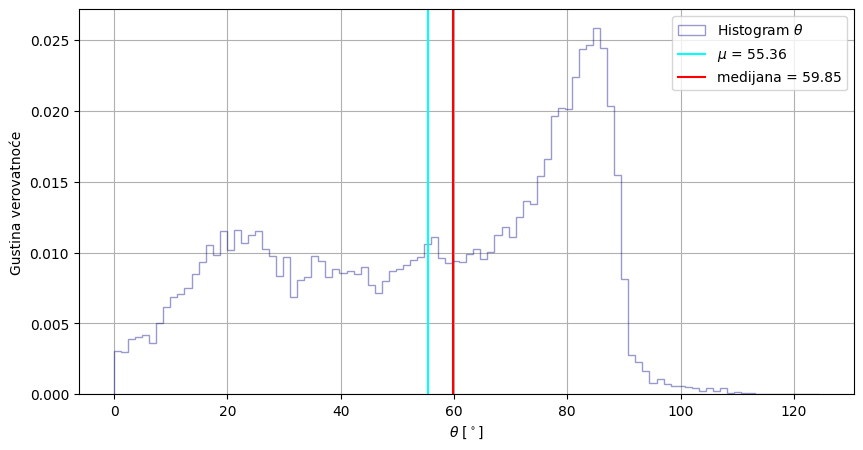

In [17]:
# Statistika vrednosti inklinacije
sv = np.mean(theta_1d)
medijana = np.median(theta_1d)
varijansa = np.var(theta_1d)
stdev = np.std(theta_1d)
s = skew(theta_1d)
k = kurtosis(theta_1d)
moda = mode(theta_1d)
q25, q50, q75 = np.percentile(theta_1d, [25, 50, 75])
devG=q75-q25 

print(f"Srednja vrijednost: {sv:.2f}")
print(f"Medijana:{medijana:.2f}")
print(f"Varijansa:{varijansa:.2f}")
print(f"Standardna devijacija: {stdev:.2f}")
print(f"Asimetričnost: {s:.2f}")
print(f"Kurtosis: {k:.2f}")
print(f"Mod: {moda[0]:.2f}")
print(f"25. percentil: {q25:.2f}")
print(f"50. percentil: {q50:.2f}")
print(f"75. percentil: {q75:.2f}")
print(f"Devijacija:{devG:.2f}")


plt.figure(figsize=(10, 5))
plt.hist(theta_1d, bins=100, density=True, histtype='step', alpha=0.4, color='navy', label='Histogram ' r'$\theta$')
plt.axvline(sv, color='cyan', linestyle='-', label=fr'$\mu$ = {sv:.2f}')
plt.axvline(medijana, color='red', linestyle='-', label=fr'medijana = {medijana:.2f}')
plt.xlabel(r'$\theta$ [$^\circ$]')
plt.ylabel('Gustina verovatnoće')
plt.title('')
plt.legend()
plt.grid()
plt.show()

Srednja vrijednost: -0.57
Medijana:-1.43
Varijansa:719.21
Standardna devijacija: 26.82
Asimetričnost: 0.44
Kurtosis: 5.74
Mod: -76.73
25. percentil: -11.84
50. percentil: -1.43
75. percentil: 9.26
Devijacija:21.10


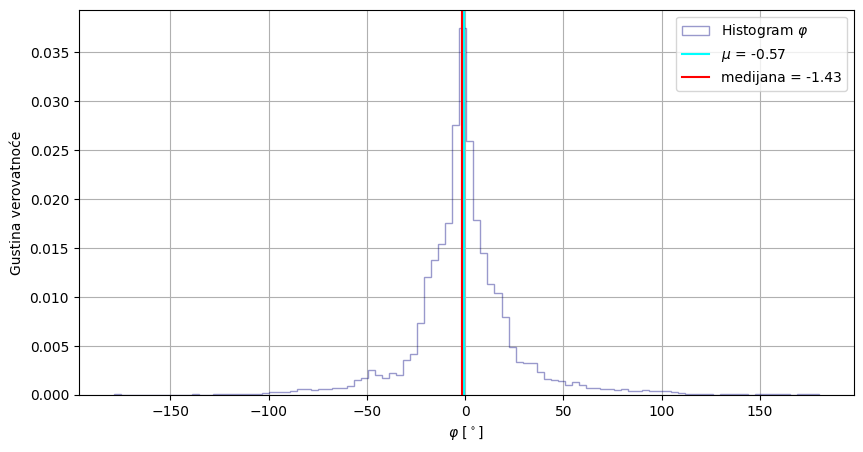

In [18]:
# Statistika vrednosti azimuta
sv = np.mean(phi_1d)
medijana = np.median(phi_1d)
varijansa = np.var(phi_1d)
stdev = np.std(phi_1d)
s = skew(phi_1d)
k = kurtosis(phi_1d)
moda = mode(phi_1d)
q25, q50, q75 = np.percentile(phi_1d, [25, 50, 75])
devG=q75-q25 

print(f"Srednja vrijednost: {sv:.2f}")
print(f"Medijana:{medijana:.2f}")
print(f"Varijansa:{varijansa:.2f}")
print(f"Standardna devijacija: {stdev:.2f}")
print(f"Asimetričnost: {s:.2f}")
print(f"Kurtosis: {k:.2f}")
print(f"Mod: {moda[0]:.2f}")
print(f"25. percentil: {q25:.2f}")
print(f"50. percentil: {q50:.2f}")
print(f"75. percentil: {q75:.2f}")
print(f"Devijacija:{devG:.2f}")


plt.figure(figsize=(10, 5))
plt.hist(phi_1d, bins=100, density=True, histtype='step', alpha=0.4, color='navy', label='Histogram ' r'$\varphi$')
plt.axvline(sv, color='cyan', linestyle='-', label=fr'$\mu$ = {sv:.2f}')
plt.axvline(medijana, color='red', linestyle='-', label=fr'medijana = {medijana:.2f}')
plt.xlabel(r'$\varphi$ [$^\circ$]')
plt.ylabel('Gustina verovatnoće')
plt.title('')
plt.legend()
plt.grid()
plt.show()

Deskriptivne statistike daju sažet opis raspodele podataka, ali njihova pouzdanost zavisi od oblika raspodele. Ako je raspodela približno simetrična i nema izražene repove ili ekstremne vrednosti, srednja vrednost $\bar{x}$ i standardna devijacija $s$ dobro opisuju tipičnu vrednost i rasipanje podataka. Međutim, za raspodele koje su asimetrične, imaju više maksimuma ili dugačke repove, ove statistike postaju manje robusne. 
Srednja vrednost nije toliko pouzdana jer zavisi od svih vrednosti u uzorku, pa ekstremne vrednosti ili repovi mogu značajno da je pomere. Za standardnu devijaciju važi isto, jer se pri njenom računanju odstupanja kvadriraju, pa one udaljene vrednosti imaju veliki uticaj na rezultat. Zbog toga $\bar{x}$ i s mogu dati nepotpunu sliku kada raspodela nije normalna.

Medijana je pouzdanija mera centralne vrednosti, jer zavisi od položaja srednjeg člana u sortiranom nizu, a ne od konkretnih ekstremnih vrednosti kao $\bar{x}$. Zato bolje opisuje tipičnu vrednost kod asimetričnih raspodela ili raspodela sa repovima. Slično tome, veličina $\sigma_G$ predstavlja rasipanje centralnih 50% podataka i manje je osetljiva na ekstremne vrednosti od standardne devijacije.

Asimetričnost i kurtosis dodatno opisuju oblik raspodele. Asimetričnost pokazuje da li je raspodela nagnuta ka manjim ili ka većim vrednostima. Kurtosis opisuje odstupanje raspodele od normalne raspodele u pogledu šiljatosti centralnog dela i izraženosti krajeva. Pošto i ove veličine mogu biti osetljive na ekstremne vrednosti, ne treba ih tumačiti izolovano, već zajedno sa histogramom.

Zbog toga je najpouzdanije deskriptivne statistike posmatrati zajedno sa oblikom histograma. U ovom slučaju histogrami pokazuju da raspodele nisu idealno normalne pa su zato medijana i $\sigma_G$ pouzdanije.

## ČETVRTI ZADATAK

Odrediti proveru centralne granične teoreme za sva tri parametra B, $\theta$, $\varphi$. Komentarisati.

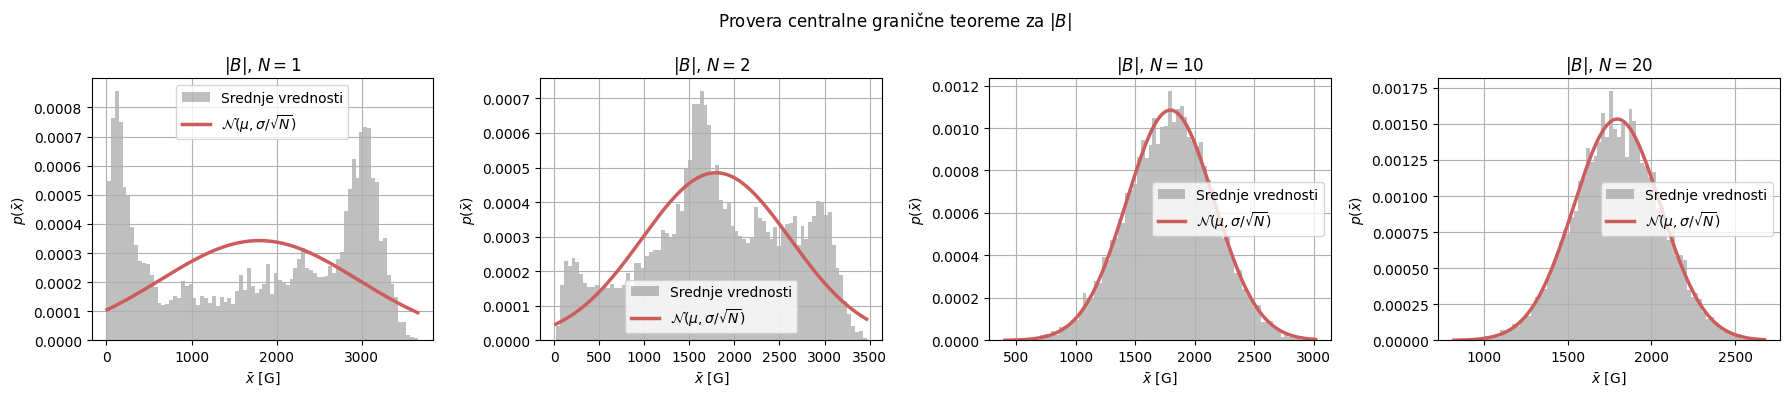

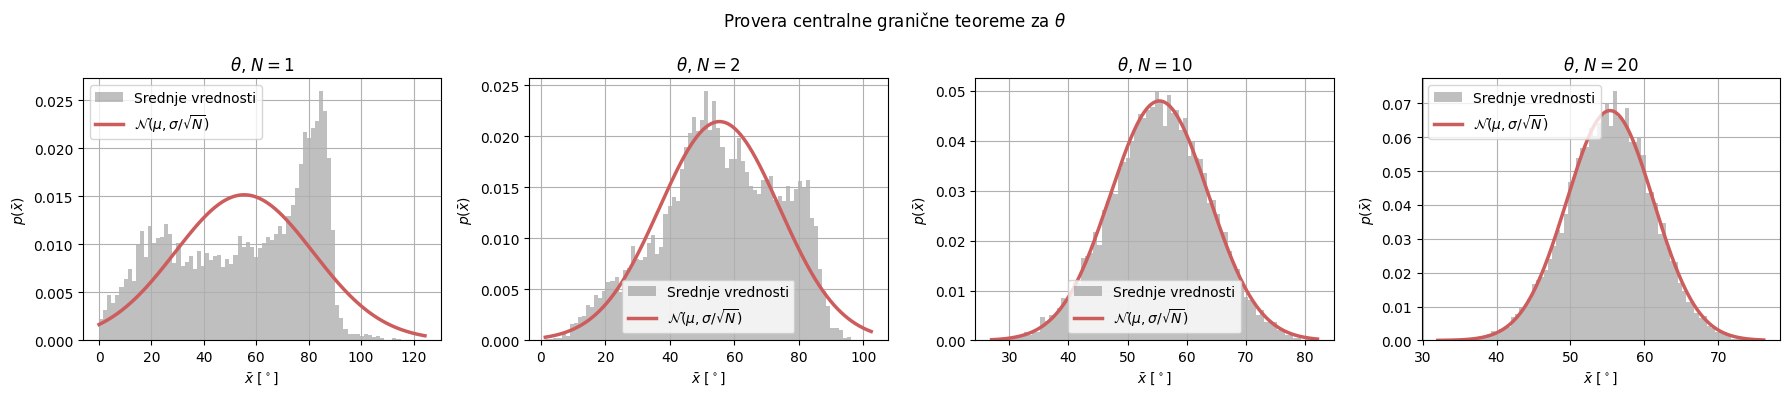

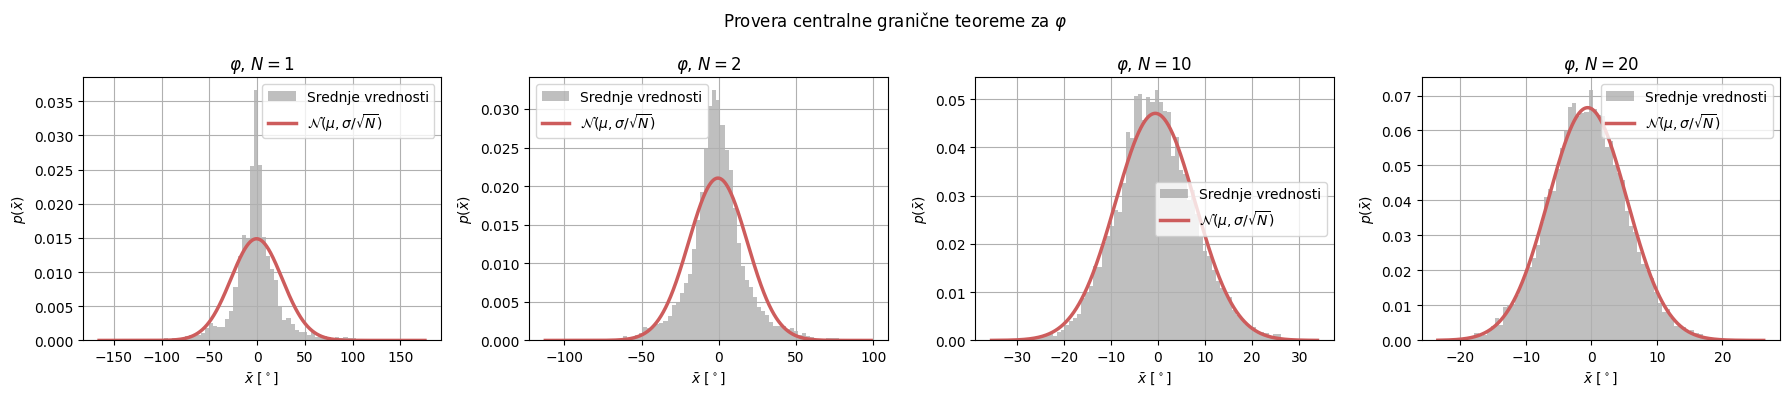

In [19]:
parametri = [
    (B_1d, r'$|B|$', r'[G]'),
    (theta_1d, r'$\theta$', r'[$^\circ$]'),
    (phi_1d, r'$\varphi$', r'[$^\circ$]')
]

N_lista = [1, 2, 10, 20]
broj_uzoraka = 10000

np.random.seed(42)

#CGT za svaki parametar
for podaci, naziv, jedinica in parametri:

    mu = np.mean(podaci)
    sigma = np.std(podaci)

    fig, axes = plt.subplots(1, 4, figsize=(18, 4))

    for i, N in enumerate(N_lista):

        # ravimo mnogo uzoraka veličine N iz empirijskih podataka
        uzorci = np.random.choice(
            podaci,
            size=(broj_uzoraka, N),
            replace=True
        )

        #računamo srednju vrednost svakog uzorka
        srednje = np.mean(uzorci, axis=1)

        #normalna raspodela očekivana po CGT
        mu_cgt = mu
        sigma_cgt = sigma / np.sqrt(N)

        x = np.linspace(np.min(srednje), np.max(srednje), 1000)
        pdf = norm.pdf(x, loc=mu_cgt, scale=sigma_cgt)

        axes[i].hist(
            srednje,
            bins=80,
            density=True,
            histtype='stepfilled',
            alpha=0.5,
            color='grey',
            label='Srednje vrednosti'
        )


        axes[i].plot(
            x,
            pdf,
            color='indianred',
            linewidth=2.5,
            label=rf'$\mathcal{{N}}(\mu, \sigma/\sqrt{{N}})$'
        )

        axes[i].set_title(rf'{naziv}, $N={N}$')
        axes[i].set_xlabel(rf'$\bar{{x}}$ {jedinica}')
        axes[i].set_ylabel(r'$p(\bar{x})$')
        axes[i].legend()
        axes[i].grid()

    plt.suptitle(rf'Provera centralne granične teoreme za {naziv}')
    plt.tight_layout()
    plt.show()

Centralna granična teorema proverena je tako što su za svaki parametar $|B|$, $\theta$ i $\varphi$ formirani nasumični uzorci veličine N, a zatim je za svaki uzorak izračunata srednja vrednost $\bar{x}$. Histogrami zato ne prikazuju direktno raspodelu početnih vrednosti, već raspodelu srednjih vrednosti uzoraka.

Za N=1, raspodela srednjih vrednosti odgovara originalnoj raspodeli parametra. Zbog toga se kod parametara koji imaju asimetrične, široke ili višemodalne raspodele još uvek jasno vidi oblik početnog histograma. U tom slučaju normalna kriva ne mora dobro da opisuje podatke.

Kako se N povećava, raspodela srednjih vrednosti postaje sve uža i sve više se grupiše oko srednje vrednosti $\mu$ što je očekivano, jer standardna devijacija srednje vrednosti opada kao: $$\sigma_{\bar{x}} = \frac{\sigma}{\sqrt{N}}$$

Zato se za veće vrednosti N, na primer N=10 i N=20, histogrami srednjih vrednosti sve bolje poklapaju sa normalnom raspodelom prikazanom preko njih. Odstupanja od idealne normalne raspodele i za veliko N mogu ostati vidljiva. To se naročito vidi kod $|B|$ i $\theta$ jer originalna raspodela ovih parametara ima složen oblik i širok opseg vrednosti. Ipak, u odnosu na slučaj N=1, raspodela srednjih vrednosti za veći uzorak se približava obliku normalne raspodele.

Na osnovu dobijenih histograma može se zaključiti da je centralna granična teorema kvalitativno potvrđena: iako početne raspodele parametara nisu nužno normalne, raspodele njihovih srednjih vrednosti za veće veličine uzorka teže normalnoj raspodeli, uz smanjenje širine kao $\frac{1}{N}$.

## PETI ZADATAK

Magnetni pritisak može se izračunati kao $P = \frac{B^2}{2\mu_{0}}$, gde je $\mu_{0} = 4\pi \cdot 10^{-7}$ H/m, sa tim da je |B| [T]. Smatrati da se propagacija greške može pisati kao:

$$s_{p} = s_{B}\left| \frac{dP}{dB} \right|$$

Proveriti koliko ovako izračunata vrednost $s_p$ odstupa od one izračunate direktno iz P.

In [ ]:
B_T = B_1d * 1e-4          #[T] pošto je dato u [G]
mu0 = 4 * np.pi * 1e-7     #[H/m]



P = B_T**2 / (2 * mu0)     #magnetni pritisak za svaki piksel
s_P = np.std(P, ddof=1)    #direktno izračunata standardna devijacija iz pritiska


s_B = np.std(B_T, ddof=1)   #standardna devijacija magnetnog polja
B_mean = np.mean(B_T)       #srednja vrednost magnetnog polja


s_P_prop = s_B * abs(B_mean / mu0)    #propagacija greške

#odstupanje
razlika = s_P_prop - s_P
relativna_razlika = razlika / s_P * 100

print(f"s_P direktno iz P = {s_P:.3e} Pa")
print(f"s_P propagacijom = {s_P_prop:.3e} Pa")
print(f"Razlika = {razlika:.3e} Pa")
print(f"Relativno odstupanje = {relativna_razlika:.2f} %")

s_P direktno iz P = 1.574e+04 Pa
s_P propagacijom = 1.663e+04 Pa
Razlika = 8.873e+02 Pa
Relativno odstupanje = 5.64 %
